<a href="https://colab.research.google.com/github/punithamuthusamy-ux/Social-Media-Engagement-Analysis/blob/main/Module_End_Assignment_5_Python_For_Data_Analysis_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Module End  Assignment 5: Python For Data Analysis**
#**“Social Media Engagement Analytics”**






##Task 1 — Data Import & Setup

In [ ]:
import pandas as pd

# Load the CSV file
df = pd.read_csv("/content/social_media_engagement_5000.csv")

# View first 5 rows
df.head()


,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate
0,25795,43.0,Female,Brazil,496713,image,fitness,7011.0,354.0,1157.0,5726,44650,17-12-2022,81734,False,mobile,negative,#foodie #travel #love,0.190862
1,10860,33.0,Male,Brazil,157326,reel,food,11750.0,2606.0,1807.0,5947,80216,02-06-2023,5963,False,mobile,negative,#fitness,0.201493
2,86820,32.0,Female,UK,109864,text,food,4862.0,344.0,955.0,6946,44858,07-05-2023,501783,False,tablet,positive,#foodie,0.137345
3,64886,51.0,Other,France,848877,text,fitness,5350.0,1083.0,1049.0,229,70455,12-02-2023,480212,False,mobile,negative,#music #foodie #fun,0.106195
4,16265,34.0,Other,UK,449706,image,fitness,12682.0,2735.0,1300.0,4798,6019,23-05-2023,383936,False,mobile,negative,#travel,2.777372


In [ ]:
# Check/convert data types

df.dtypes


,0
user_id,int64
age,float64
gender,object
country,object
post_id,int64
post_type,object
post_category,object
likes,float64
comments,float64
shares,float64


In [ ]:
# Convert date columns to datetime

date_cols = ['posted_at']

for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce', format='%d-%m-%Y')

In [ ]:
# Display the data first 5 records

display(df.head(5))


,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate
0,25795,43.0,Female,Brazil,496713,image,fitness,7011.0,354.0,1157.0,5726,44650,2022-12-17,81734,False,mobile,negative,#foodie #travel #love,0.190862
1,10860,33.0,Male,Brazil,157326,reel,food,11750.0,2606.0,1807.0,5947,80216,2023-06-02,5963,False,mobile,negative,#fitness,0.201493
2,86820,32.0,Female,UK,109864,text,food,4862.0,344.0,955.0,6946,44858,2023-05-07,501783,False,tablet,positive,#foodie,0.137345
3,64886,51.0,Other,France,848877,text,fitness,5350.0,1083.0,1049.0,229,70455,2023-02-12,480212,False,mobile,negative,#music #foodie #fun,0.106195
4,16265,34.0,Other,UK,449706,image,fitness,12682.0,2735.0,1300.0,4798,6019,2023-05-23,383936,False,mobile,negative,#travel,2.777372


#Task 2 — Data Cleaning

**Cleaning Missing Data**

In [ ]:
# Detect missing values (isnull(), isna())

df.isnull().sum()
df.isna().sum()


,0
user_id,0
age,150
gender,150
country,0
post_id,0
post_type,0
post_category,0
likes,150
comments,150
shares,150


In [ ]:
# Handle missing values

# Impute numerical columns with median

df['age'] = df['age'].fillna(df['age'].median())
df['likes'] = df['likes'].fillna(df['likes'].median())
df['comments'] = df['comments'].fillna(df['comments'].median())
df['shares'] = df['shares'].fillna(df['shares'].median())


In [ ]:
# Impute categorical columns with mode

df['gender'].fillna(df['gender'].mode()[0], inplace=True)
df['sentiment'].fillna(df['sentiment'].mode()[0], inplace=True)


In [ ]:
# Verify that there are no more missing values

df.isnull().sum()


,0
user_id,0
age,0
gender,0
country,0
post_id,0
post_type,0
post_category,0
likes,0
comments,0
shares,0


**Duplicate Handling**

In [ ]:
# Identify & remove duplicates

df.duplicated().sum()
df.drop_duplicates(inplace=True)


**Data Formatting**

In [ ]:
# Fix incorrect data types

df.dtypes

,0
user_id,int64
age,float64
gender,object
country,object
post_id,int64
post_type,object
post_category,object
likes,float64
comments,float64
shares,float64


In [ ]:
# Standardize categories (e.g., gender labels)

df['gender'].unique()
df['country'].unique()
df['sentiment'].unique()

array(['negative', 'positive', 'neutral'], dtype=object)

In [ ]:
# Display descriptive statistics for 'likes', 'comments', and 'shares' to identify potential unrealistic values

df[['likes', 'comments', 'shares']].describe()

,likes,comments,shares
count,5000.000000,5000.000000,5000.0000
mean,10106.997400,1502.039800,1002.9106
std,5702.293017,856.393312,570.8552
min,10.000000,0.000000,0.0000
25%,5235.000000,792.000000,511.0000
50%,10105.500000,1497.000000,1012.0000
75%,14959.000000,2235.250000,1483.0000
max,19998.000000,2999.000000,1999.0000


**Feature Cleaning**

In [ ]:
#	Extract hashtag count

df['hashtag_count'] = df['hashtags'].str.count('#')

In [ ]:
display(df[['hashtags', 'hashtag_count']].head())

,hashtags,hashtag_count
0,#foodie #travel #love,3
1,#fitness,1
2,#foodie,1
3,#music #foodie #fun,3
4,#travel,1


In [ ]:
# Clean sentiment labels

df['sentiment'] = df['sentiment'].str.lower()


In [ ]:
# Count the occurrences of each sentiment label

df['sentiment'].value_counts()

,count
sentiment,
positive,2513
neutral,1527
negative,960


##Task 3 — Data Exploration using Pandas

In [ ]:
# View dataset structure using head(), tail(), shape, and columns.

# Display the first 5 rows

display(df.head())


,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate,hashtag_count
0,25795,43.0,Female,Brazil,496713,image,fitness,7011.0,354.0,1157.0,5726,44650,2022-12-17,81734,False,mobile,negative,#foodie #travel #love,0.190862,3
1,10860,33.0,Male,Brazil,157326,reel,food,11750.0,2606.0,1807.0,5947,80216,2023-06-02,5963,False,mobile,negative,#fitness,0.201493,1
2,86820,32.0,Female,UK,109864,text,food,4862.0,344.0,955.0,6946,44858,2023-05-07,501783,False,tablet,positive,#foodie,0.137345,1
3,64886,51.0,Other,France,848877,text,fitness,5350.0,1083.0,1049.0,229,70455,2023-02-12,480212,False,mobile,negative,#music #foodie #fun,0.106195,3
4,16265,34.0,Other,UK,449706,image,fitness,12682.0,2735.0,1300.0,4798,6019,2023-05-23,383936,False,mobile,negative,#travel,2.777372,1


In [ ]:
# Display the last 5 rows

display(df.tail())


,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate,hashtag_count
4995,59500,44.0,Male,Australia,441541,video,education,16210.0,2013.0,1837.0,6190,42977,2022-06-25,646147,False,mobile,positive,#travel #fun,0.466761,2
4996,22100,38.0,Other,UAE,677076,reel,education,16924.0,2734.0,1583.0,7764,34196,2022-11-18,584603,False,desktop,negative,#foodie #reels,0.621155,2
4997,67021,63.0,Female,USA,273595,text,travel,13487.0,1497.0,167.0,7466,23680,2023-04-06,483550,False,desktop,positive,#lifestyle #tech,0.679688,2
4998,29800,13.0,Female,Germany,785644,video,fitness,16894.0,1289.0,1713.0,4991,89013,2022-05-16,183295,False,tablet,positive,#reels #love #fitness,0.223518,3
4999,73400,54.0,Other,Japan,712252,text,travel,14830.0,503.0,1798.0,3743,14234,2023-03-04,585760,False,desktop,neutral,#foodie #lifestyle #fashion,1.203527,3


In [ ]:
# Display the shape of the DataFrame (rows, columns)

print(f"DataFrame Shape: {df.shape}")


DataFrame Shape: (5000, 20)


In [ ]:
# Display the column names

print("DataFrame Columns:", df.columns.tolist())


DataFrame Columns: ['user_id', 'age', 'gender', 'country', 'post_id', 'post_type', 'post_category', 'likes', 'comments', 'shares', 'watch_time_sec', 'impression_count', 'posted_at', 'follower_count', 'is_verified', 'device_type', 'sentiment', 'hashtags', 'engagement_rate', 'hashtag_count']


In [ ]:
#Check data types and info with info() and dtypes

# Data types

print("DataFrame Data Types:")
df.dtypes


DataFrame Data Types:


,0
user_id,int64
age,float64
gender,object
country,object
post_id,int64
post_type,object
post_category,object
likes,float64
comments,float64
shares,float64


In [ ]:
# Data info

print("\nDataFrame Info:")
df.info()


DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   user_id           5000 non-null   int64         
 1   age               5000 non-null   float64       
 2   gender            5000 non-null   object        
 3   country           5000 non-null   object        
 4   post_id           5000 non-null   int64         
 5   post_type         5000 non-null   object        
 6   post_category     5000 non-null   object        
 7   likes             5000 non-null   float64       
 8   comments          5000 non-null   float64       
 9   shares            5000 non-null   float64       
 10  watch_time_sec    5000 non-null   int64         
 11  impression_count  5000 non-null   int64         
 12  posted_at         5000 non-null   datetime64[ns]
 13  follower_count    5000 non-null   int64         
 14  is_veri

In [ ]:
# Generate summary statistics using describe()

display(df.describe())

,user_id,age,post_id,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,engagement_rate,hashtag_count
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.0000,5000.000000,5000.000000,5000,5000.000000,5000.000000,5000.000000
mean,54561.890800,38.440400,548042.909000,10106.997400,1502.039800,1002.9106,4014.503200,50013.732800,2022-12-28 13:21:30.240000,393698.224800,0.964356,1.998600
min,10055.000000,13.000000,100068.000000,10.000000,0.000000,0.0000,0.000000,105.000000,2022-01-01 00:00:00,87.000000,0.006363,1.000000
25%,32309.500000,26.000000,322543.500000,5235.000000,792.000000,511.0000,2017.750000,24988.250000,2022-07-03 18:00:00,194480.000000,0.145781,1.000000
50%,54374.500000,38.000000,548077.500000,10105.500000,1497.000000,1012.0000,4034.500000,49934.500000,2022-12-27 00:00:00,388982.000000,0.253896,2.000000
75%,77180.500000,51.000000,771574.500000,14959.000000,2235.250000,1483.0000,6020.250000,74662.250000,2023-06-28 00:00:00,589744.250000,0.504794,3.000000
max,99963.000000,64.000000,999455.000000,19998.000000,2999.000000,1999.0000,7998.000000,99995.000000,2023-12-31 00:00:00,799533.000000,191.504348,3.000000
std,26090.370121,14.687151,260646.957267,5702.293017,856.393312,570.8552,2308.096459,28844.939104,NaN,230927.884535,5.318029,0.812853


In [ ]:
# Analyze categorical distributions using value_counts(), unique(), and nunique()

df.select_dtypes(include=['object']).nunique()
df.select_dtypes(include=['number']).nunique()
df.select_dtypes(include=['float']).nunique()
df.select_dtypes(include=['int64']).nunique()

,0
user_id,4862
post_id,4991
watch_time_sec,3690
impression_count,4870
follower_count,4983
hashtag_count,3


In [ ]:
# Create a correlation matrix for numeric fields

numeric_df = df.select_dtypes(include=['number'])
correlation_matrix = numeric_df.corr()
display(correlation_matrix)

,user_id,age,post_id,likes,comments,shares,watch_time_sec,impression_count,follower_count,engagement_rate,hashtag_count
user_id,1.000000,-0.006688,0.020051,0.025811,-0.033395,0.013763,-0.016847,0.015326,0.010124,-0.004282,-0.013692
age,-0.006688,1.000000,-0.013153,-0.036322,-0.007284,0.013871,0.005542,0.013322,-0.024894,0.008039,0.007173
post_id,0.020051,-0.013153,1.000000,0.014526,-0.010540,0.001846,0.018374,-0.007709,-0.002844,0.010139,0.007344
likes,0.025811,-0.036322,0.014526,1.000000,-0.018421,0.004712,0.008710,0.007952,-0.022982,0.093520,-0.002190
comments,-0.033395,-0.007284,-0.010540,-0.018421,1.000000,0.006142,-0.016351,-0.009395,-0.011733,0.000051,-0.015230
shares,0.013763,0.013871,0.001846,0.004712,0.006142,1.000000,0.014658,-0.005204,-0.010783,0.021724,0.013379
watch_time_sec,-0.016847,0.005542,0.018374,0.008710,-0.016351,0.014658,1.000000,-0.004335,0.002761,-0.001148,-0.023301
impression_count,0.015326,0.013322,-0.007709,0.007952,-0.009395,-0.005204,-0.004335,1.000000,-0.015513,-0.232226,-0.002714
follower_count,0.010124,-0.024894,-0.002844,-0.022982,-0.011733,-0.010783,0.002761,-0.015513,1.000000,0.002292,0.008802
engagement_rate,-0.004282,0.008039,0.010139,0.093520,0.000051,0.021724,-0.001148,-0.232226,0.002292,1.000000,0.005319


In [ ]:
# Use groupby() to summarize metrics (e.g., avg likes by post type, impressions by country)

# Average likes by post type

avg_likes_by_post_type = df.groupby('post_type')['likes'].mean()
print("\nAverage Likes by Post Type:\n")
display(avg_likes_by_post_type)



Average Likes by Post Type:



,likes
post_type,
image,10104.865277
reel,10037.802416
text,10100.148193
video,10188.600000


In [ ]:
# Total impressions by country

total_impressions_by_country = df.groupby('country')['impression_count'].sum()
print("\nTotal Impressions by Country:\n")
display(total_impressions_by_country)



Total Impressions by Country:



,impression_count
country,
Australia,23834767
Brazil,24793360
Canada,24984716
France,25656926
Germany,23816649
India,28067377
Japan,23418816
UAE,24610992
UK,25201861


##Task 4 — Data Wrangling

In [ ]:
# Use merge, concat, or join if combining DataFrames

# --- Demonstrating pandas.concat() ---
print("\n--- Demonstrating pandas.concat() ---")
# Split the DataFrame into two parts for vertical concatenation
df_part1 = df.iloc[:2500]
df_part2 = df.iloc[2500:]



--- Demonstrating pandas.concat() ---


In [ ]:
# Concatenate them back together (vertical concatenation is default)

df_concatenated = pd.concat([df_part1, df_part2])
print(f"Original df shape: {df.shape}")
print(f"Concatenated df_concatenated shape: {df_concatenated.shape}")


Original df shape: (5000, 20)
Concatenated df_concatenated shape: (5000, 20)


In [ ]:
# --- Demonstrating pandas.merge() ---
print("\n--- Demonstrating pandas.merge() ---")

# Create a dummy DataFrame with additional post information to merge
# This simulates data coming from a different source that we want to add to our main df

dummy_post_data = pd.DataFrame({
    'post_id': df['post_id'].sample(n=10, random_state=42).tolist(), # Take a sample of existing post_ids
    'post_score': [8.5, 7.2, 9.1, 6.8, 7.5, 8.0, 9.5, 7.0, 6.5, 8.8]
})



--- Demonstrating pandas.merge() ---


In [ ]:
print("Dummy DataFrame for merge:")
display(dummy_post_data)

Dummy DataFrame for merge:


,post_id,post_score
0,823040,8.5
1,844502,7.2
2,636761,9.1
3,769426,6.8
4,561015,7.5
5,670722,8.0
6,697539,9.5
7,538949,7.0
8,230293,6.5
9,159668,8.8


In [ ]:
# Merge df with the dummy_post_data on 'post_id'
# Using a 'left' merge to keep all records from the original df

df_merged_with_post_scores = pd.merge(df, dummy_post_data, on='post_id', how='left')


In [ ]:
print("DataFrame after merging (showing post_id and new 'post_score' column):")
display(df_merged_with_post_scores[['post_id', 'post_score']].head())

# Note: df.join() is similar to merge but typically operates on indexes.
# If you need to join on a column, it's often more explicit to use merge.


DataFrame after merging (showing post_id and new 'post_score' column):


,post_id,post_score
0,496713,NaN
1,157326,NaN
2,109864,NaN
3,848877,NaN
4,449706,NaN


In [ ]:
# Create new fields such as engagement_score, log-transformed metrics (optional), and hashtag count.

import numpy as np

# Create engagement_score
# To avoid division by zero, we can add a small constant or handle cases where follower_count is 0
df['engagement_score'] = (df['likes'] + df['comments'] + df['shares']) / (df['follower_count'] + 1) # Added +1 to avoid division by zero


In [ ]:
# Create log-transformed metrics (optional)

df['log_likes'] = np.log1p(df['likes'])
df['log_comments'] = np.log1p(df['comments'])


In [ ]:

# Display the new columns to verify

print("DataFrame with new 'engagement_score', 'log_likes', and 'log_comments' fields:")
display(df[['likes', 'comments', 'shares', 'follower_count', 'engagement_score', 'log_likes', 'log_comments']].head())


DataFrame with new 'engagement_score', 'log_likes', and 'log_comments' fields:


,likes,comments,shares,follower_count,engagement_score,log_likes,log_comments
0,7011.0,354.0,1157.0,81734,0.104264,8.855378,5.872118
1,11750.0,2606.0,1807.0,5963,2.710094,9.371694,7.865955
2,4862.0,344.0,955.0,501783,0.012278,8.489411,5.843544
3,5350.0,1083.0,1049.0,480212,0.015581,8.585039,6.988413
4,12682.0,2735.0,1300.0,383936,0.043541,9.448018,7.914252


In [ ]:
# Perform groupby summaries by post_type, country, and sentiment

# Group by post_type and calculate mean engagement metrics

print("\nAverage Engagement Metrics by Post Type:")
avg_by_post_type = df.groupby('post_type')[['likes', 'comments', 'shares', 'engagement_score']].mean()
display(avg_by_post_type)



Average Engagement Metrics by Post Type:


,likes,comments,shares,engagement_score
post_type,,,,
image,10104.865277,1525.235766,1019.289495,0.109599
reel,10037.802416,1504.187062,982.042089,0.117729
text,10100.148193,1499.106024,1013.989558,0.112473
video,10188.600000,1479.160000,996.834286,0.239181


In [ ]:
# Group by country and calculate mean engagement metrics

print("\nAverage Engagement Metrics by Country:")
avg_by_country = df.groupby('country')[['likes', 'comments', 'shares', 'engagement_score']].mean()
display(avg_by_country)



Average Engagement Metrics by Country:


,likes,comments,shares,engagement_score
country,,,,
Australia,10294.124746,1485.803245,1029.693712,0.131640
Brazil,9886.689484,1490.434524,1008.859127,0.105833
Canada,10063.066277,1546.582846,996.245614,0.121125
France,10372.876008,1478.695565,1051.812500,0.095322
Germany,10130.458163,1531.826531,973.379592,0.122322
India,9962.468224,1494.917757,1035.315888,0.095927
Japan,10088.862288,1530.434322,959.351695,0.111773
UAE,10227.487078,1541.214712,989.075547,0.369635
UK,9935.650101,1463.042596,985.681542,0.156989


In [ ]:
# Group by sentiment and calculate mean engagement metrics

print("\nAverage Engagement Metrics by Sentiment:")
avg_by_sentiment = df.groupby('sentiment')[['likes', 'comments', 'shares', 'engagement_score']].mean()
display(avg_by_sentiment)



Average Engagement Metrics by Sentiment:


,likes,comments,shares,engagement_score
sentiment,,,,
negative,10208.096875,1516.094792,1007.307292,0.284645
neutral,9923.194499,1528.404060,996.565160,0.111559
positive,10180.062077,1480.650617,1005.086749,0.110280


##Task 5 — Statistical Analysis

In [ ]:
# Compute descriptive statistics

import numpy as np

# Define the columns for which to compute descriptive statistics
columns_to_analyze = ['likes', 'comments', 'shares', 'watch_time_sec', 'engagement_rate', 'follower_count']



In [ ]:
# Compute descriptive statistics
print("\n--- Descriptive Statistics for Selected Columns ---\n")


for col in columns_to_analyze:
    print(f"### Column: {col}\n")



--- Descriptive Statistics for Selected Columns ---

### Column: likes

### Column: comments

### Column: shares

### Column: watch_time_sec

### Column: engagement_rate

### Column: follower_count



In [ ]:
    # Basic descriptive statistics (mean, std, min, max, 25%, 50%, 75%)

    print("**Summary Statistics (from describe()):**")
    display(df[col].describe().to_frame().T)
    print("\n")



**Summary Statistics (from describe()):**


,count,mean,std,min,25%,50%,75%,max
follower_count,5000.0,393698.2248,230927.884535,87.0,194480.0,388982.0,589744.25,799533.0


In [ ]:

    # Mode (can have multiple values)

    mode_val = df[col].mode()
    print("**Mode:**")
    if not mode_val.empty:
        display(mode_val.to_frame().T)
    else:
        print("No unique mode found.")
        print("\n")


**Mode:**


,0
follower_count,497502


In [ ]:

    # Variance

    print("**Variance:**")
    print(f"{df[col].var():.2f}")
    print("\n")


**Variance:**
53327687855.63




In [ ]:

    # Skewness (optional)

    print("**Skewness:**")
    print(f"{df[col].skew():.2f}")
    print("\n")


**Skewness:**
0.04




In [ ]:

    # Kurtosis (optional)

    print("**Kurtosis:**")
    print(f"{df[col].kurt():.2f}")
    print("\n" + "-"*50 + "\n")


**Kurtosis:**
-1.19

--------------------------------------------------



##Task 6 — Data Visualization

##**Matplotlib**

##Scatter

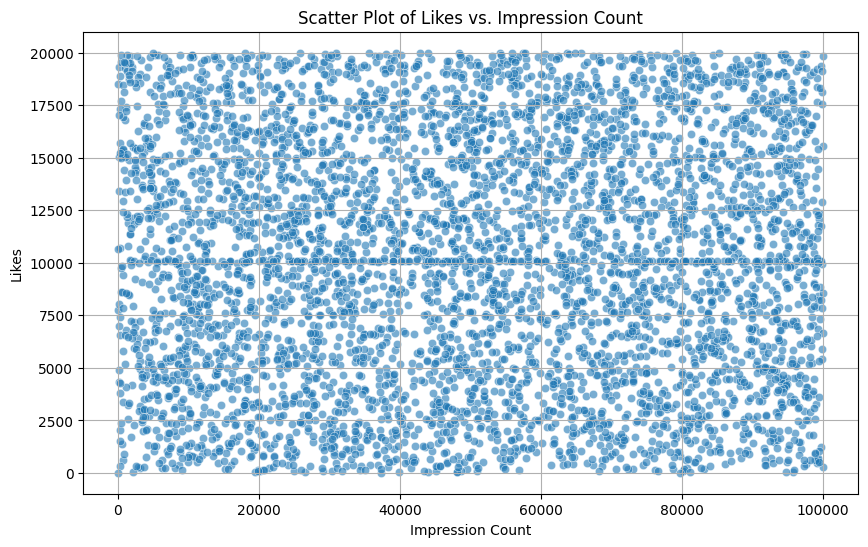

In [ ]:
# Scatter plot: Impressions Vs. Likes

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='impression_count', y='likes', alpha=0.6)
plt.title('Scatter Plot of Likes vs. Impression Count')
plt.xlabel('Impression Count')
plt.ylabel('Likes')
plt.grid(True)
plt.show()

##Line

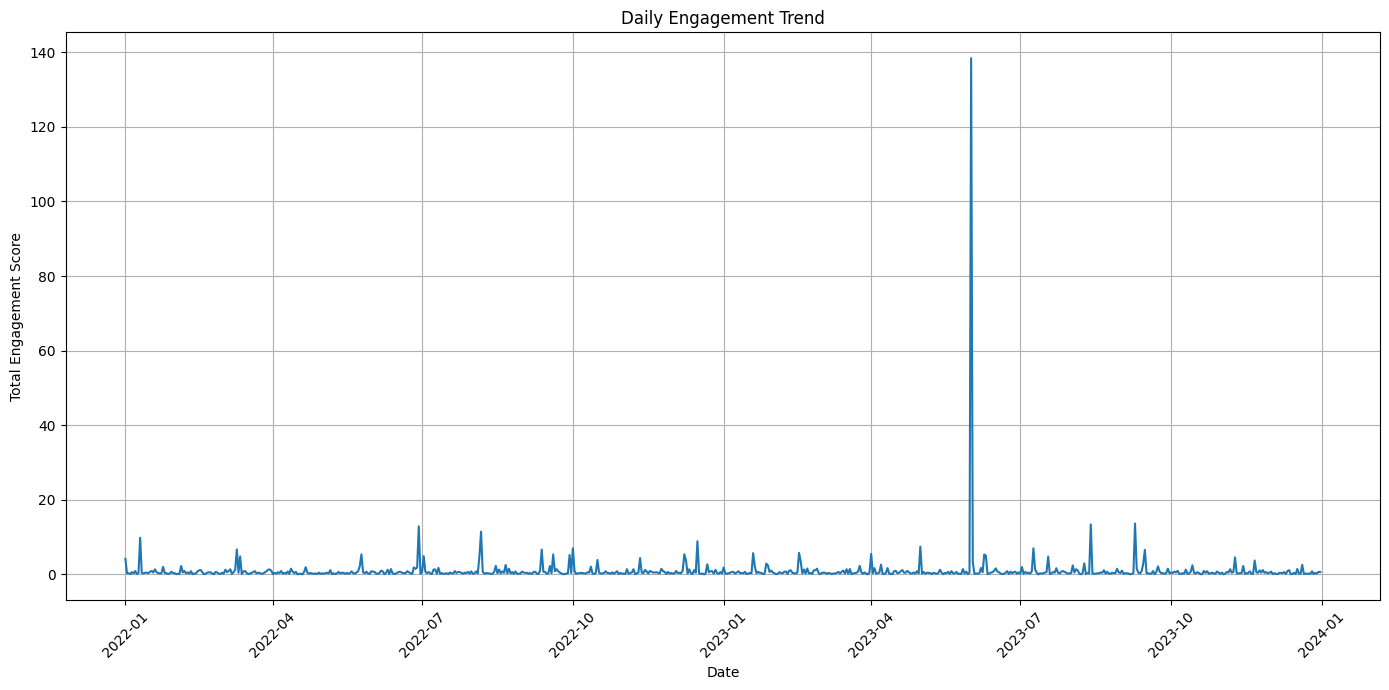

In [ ]:
# Line plot: Daily engagement trend

# Extract date from 'posted_at' and calculate daily total engagement score
df['post_date'] = df['posted_at'].dt.date
daily_engagement = df.groupby('post_date')['engagement_score'].sum().reset_index()

plt.figure(figsize=(14, 7))
sns.lineplot(data=daily_engagement, x='post_date', y='engagement_score')
plt.title('Daily Engagement Trend')
plt.xlabel('Date')
plt.ylabel('Total Engagement Score')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##Bar

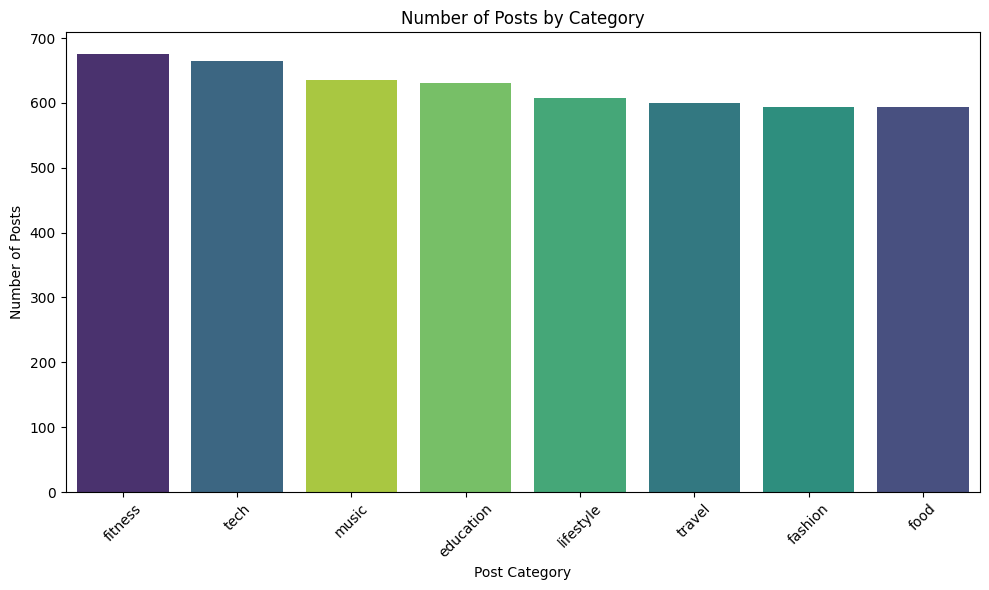

In [ ]:
# Bar plot: Posts by Category

plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='post_category', hue='post_category', palette='viridis', order=df['post_category'].value_counts().index, legend=False)
plt.title('Number of Posts by Category')
plt.xlabel('Post Category')
plt.ylabel('Number of Posts')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##Pie

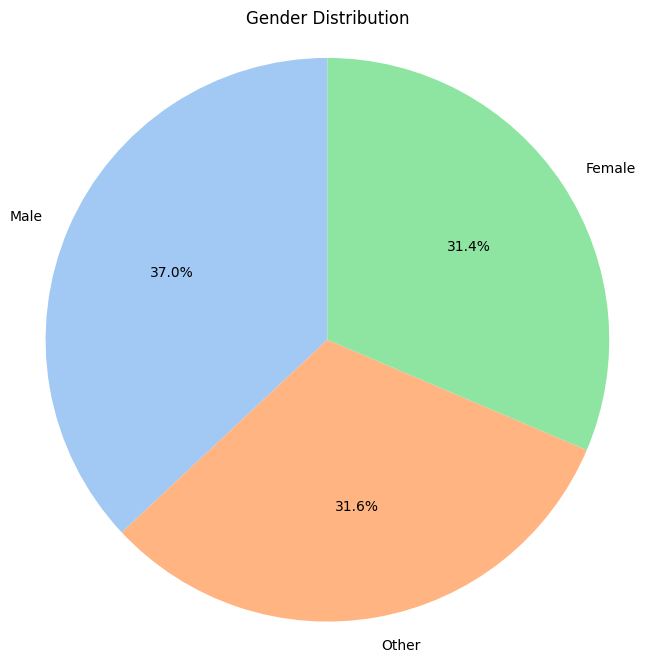

In [ ]:
# Pie chart: Gender distribution

gender_counts = df['gender'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('pastel'))
plt.title('Gender Distribution')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

##Histogram

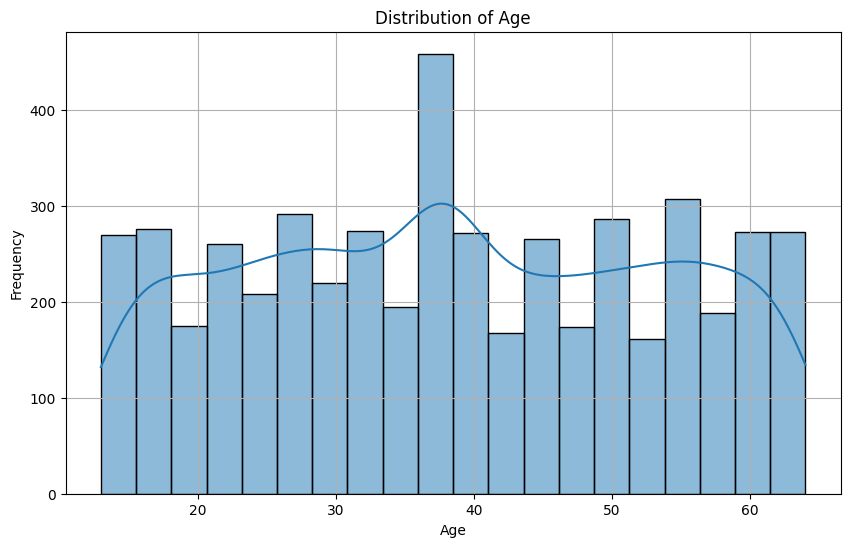

In [ ]:
# Histogram: Age distribution

plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='age', bins=20, kde=True)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

##Box

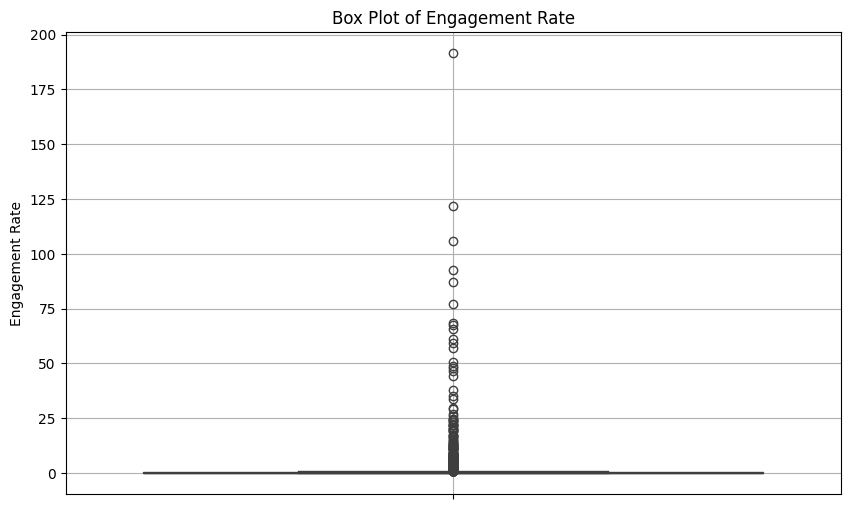

In [ ]:
# Box plot: Engagement Rate

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, y='engagement_rate')
plt.title('Box Plot of Engagement Rate')
plt.ylabel('Engagement Rate')
plt.grid(True)
plt.show()

#**Seaborn**

##Count Plot

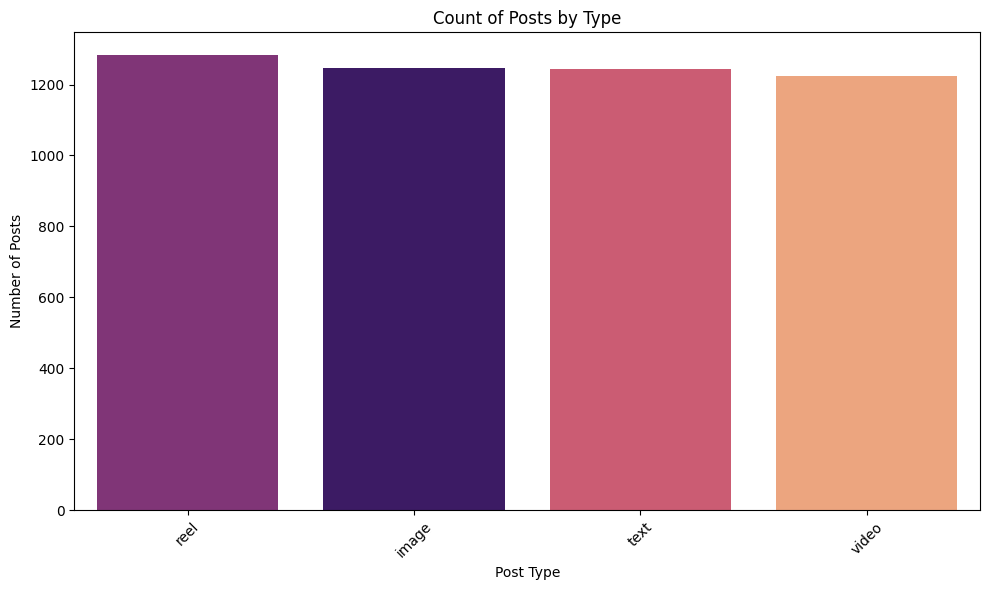

In [ ]:
# Count plot: post type

plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='post_type', hue='post_type', palette='magma', order=df['post_type'].value_counts().index, legend=False)
plt.title('Count of Posts by Type')
plt.xlabel('Post Type')
plt.ylabel('Number of Posts')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##Bar Plot

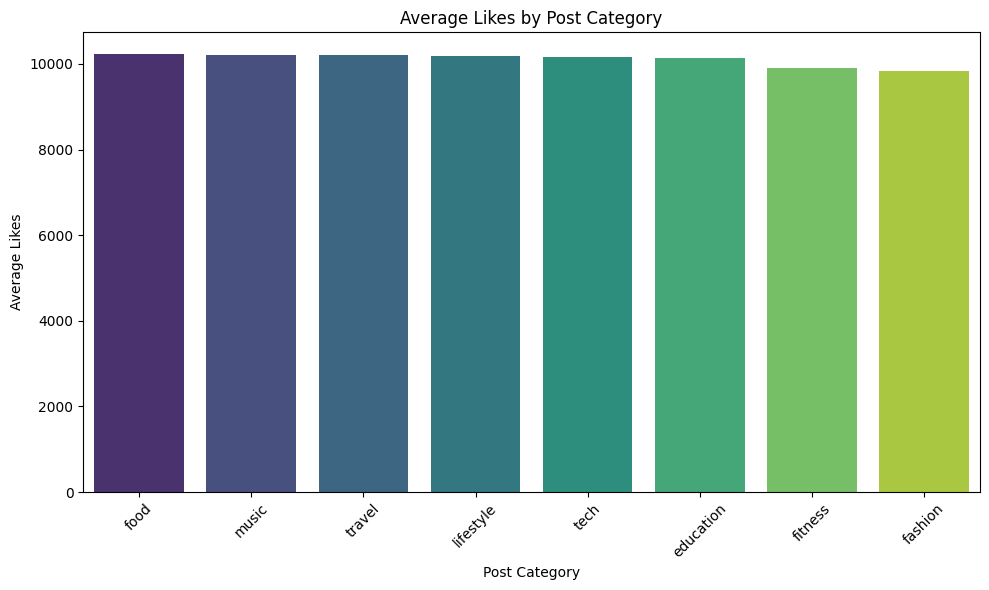

In [ ]:
# Bar plot: Average Likes by Category

avg_likes_by_category = df.groupby('post_category')['likes'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=avg_likes_by_category, x='post_category', y='likes', hue='post_category', palette='viridis', legend=False)
plt.title('Average Likes by Post Category')
plt.xlabel('Post Category')
plt.ylabel('Average Likes')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##Violin Plot

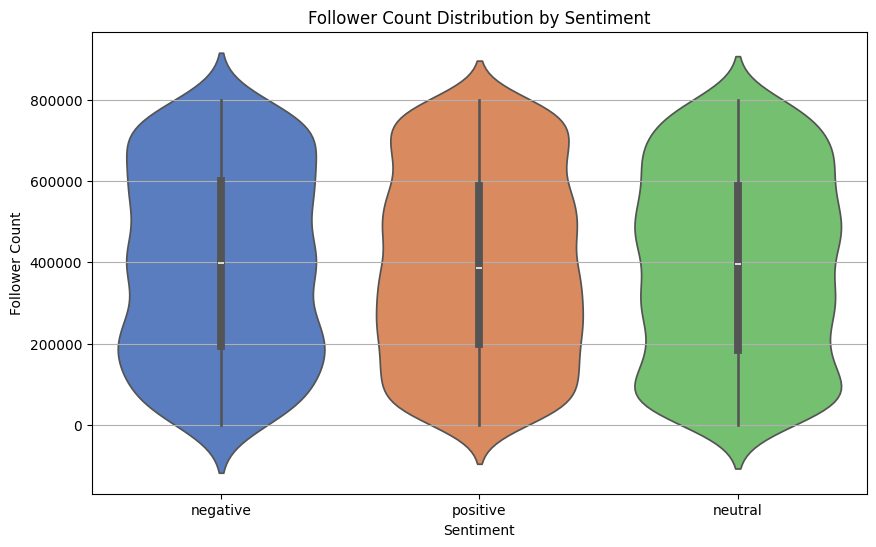

In [ ]:
# Violin plot: followers vs sentiment

plt.figure(figsize=(10, 6))
sns.violinplot(data=df, x='sentiment', y='follower_count', hue='sentiment', palette='muted', legend=False)
plt.title('Follower Count Distribution by Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Follower Count')
plt.grid(axis='y')
plt.show()

##Pair Plot

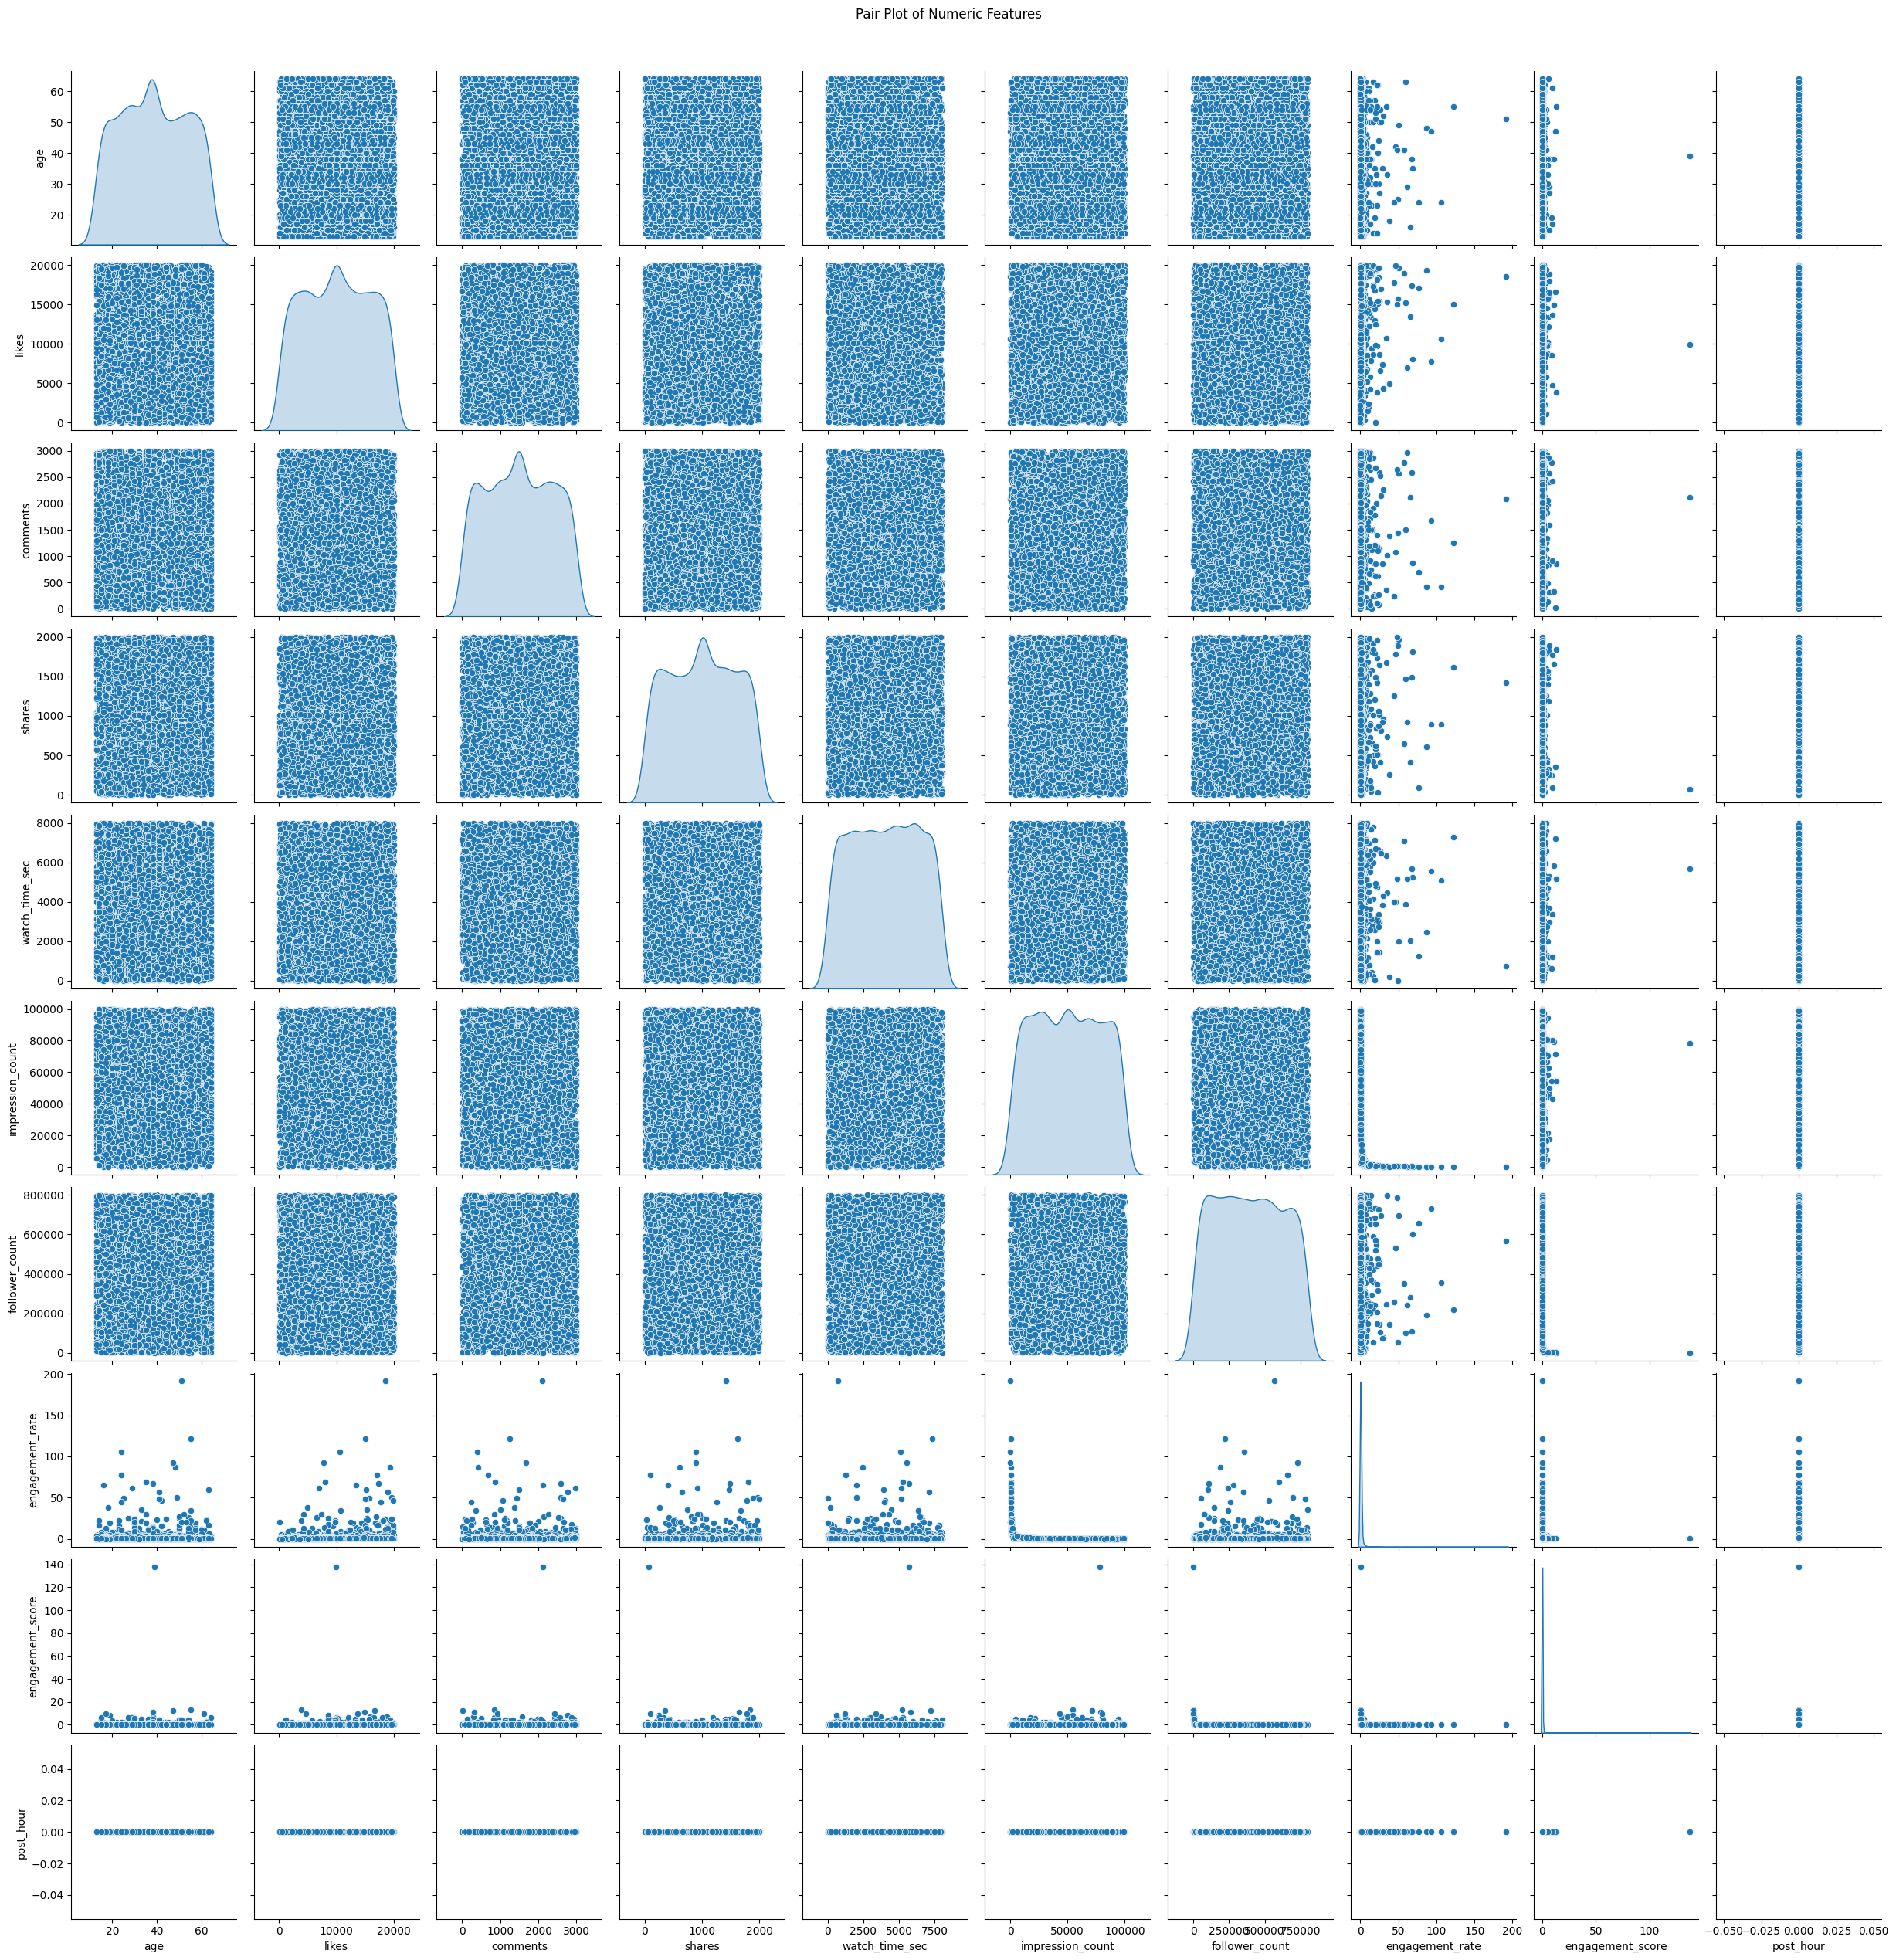

In [ ]:
# Pair plot: numeric features

import seaborn as sns
import matplotlib.pyplot as plt

# Select numeric columns only
numeric_df = df.select_dtypes(include='number')

# Drop ID columns (not useful for analysis)
numeric_df = numeric_df.drop(columns=['user_id', 'post_id'])

# Create pair plot
sns.pairplot(numeric_df, diag_kind='kde')
plt.suptitle("Pair Plot of Numeric Features", y=1.02)
plt.show()


##Heatmap

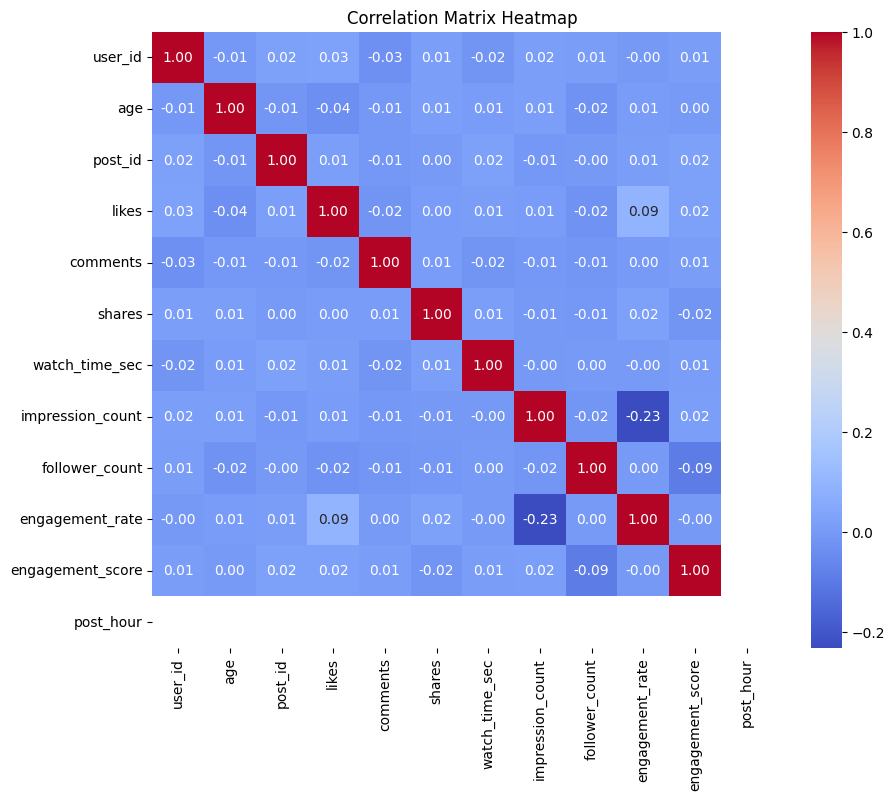

In [ ]:
# Heatmap: correlation matrix

import matplotlib.pyplot as plt
import seaborn as sns

# Correlation matrix
corr = df.select_dtypes('number').corr()

# Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')

plt.title('Correlation Matrix Heatmap')
plt.show()


##**Plotly (Interactive)**

In [ ]:
import plotly.express as px

# Interactive Line Chart: Daily Engagement Trend
# Ensure 'daily_engagement' DataFrame is available from previous steps
# If not, recalculate it:
# df['post_date'] = df['posted_at'].dt.date
# daily_engagement = df.groupby('post_date')['engagement_score'].sum().reset_index()

fig = px.line(
    daily_engagement,
    x='post_date',
    y='engagement_score',
    title='Interactive Daily Engagement Trend',
    labels={
        'post_date': 'Date',
        'engagement_score': 'Total Engagement Score'
    }
)

fig.update_layout(height=600, width=1000) # Adjust plot size
fig.show()

#Final Insights should include the following analysis

**Content Performance**

In [ ]:
# Which post types have the highest engagement?

# Find the post type with the highest engagement score
highest_engagement_post_type = avg_by_post_type.loc[avg_by_post_type['engagement_score'].idxmax()]

print("Post type with the highest engagement score:")
display(highest_engagement_post_type)

Post type with the highest engagement score:


,video
likes,10188.600000
comments,1479.160000
shares,996.834286
engagement_score,0.239181


In [ ]:
# Which content category has the highest average likes?

# Find the content category with the highest average likes
highest_avg_likes_category = avg_likes_by_category.loc[avg_likes_by_category['likes'].idxmax()]

print("Content category with the highest average likes:")
display(highest_avg_likes_category)

Content category with the highest average likes:


,0
post_category,food
likes,10225.522766


In [ ]:
# Which countries have the highest average engagement rate?

# Find the country with the highest average engagement score
highest_engagement_country = avg_by_country.loc[avg_by_country['engagement_score'].idxmax()]

print("Country with the highest average engagement rate:")
display(highest_engagement_country)

Country with the highest average engagement rate:


,UAE
likes,10227.487078
comments,1541.214712
shares,989.075547
engagement_score,0.369635


**User Trends**

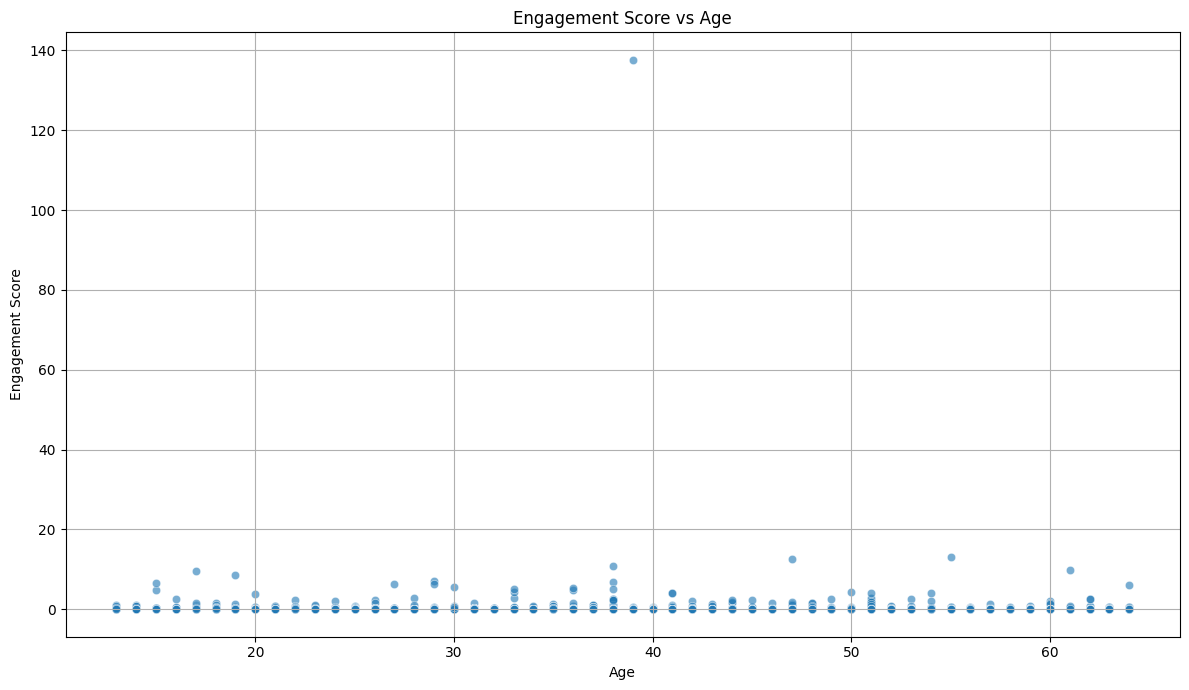

In [ ]:
# How age affects engagement

import matplotlib.pyplot as plt
import seaborn as sns

# Create engagement_score if it does not exist
if 'engagement_score' not in df.columns:
    df['engagement_score'] = (df['likes'] + df['comments'] + df['shares']) / (df['follower_count'] + 1)

# Plot: How age affects engagement
plt.figure(figsize=(12, 7))
sns.scatterplot(data=df, x='age', y='engagement_score', alpha=0.6)

plt.title('Engagement Score vs Age')
plt.xlabel('Age')
plt.ylabel('Engagement Score')
plt.grid(True)

plt.tight_layout()
plt.show()


In [ ]:
# Performance difference for verified accounts

avg_engagement = df.groupby('is_verified')[['likes', 'comments', 'shares', 'engagement_score']].mean()

print("Average Engagement Metrics by Verification Status:")
avg_engagement


Average Engagement Metrics by Verification Status:


,likes,comments,shares,engagement_score
is_verified,,,,
False,10137.201129,1505.511401,1001.599292,0.149245
True,9824.533126,1469.573499,1015.173913,0.096491


**Behavioral Insights**

In [ ]:
# Best time of day for impressions

# Total impressions by hour
hourly_impressions = df.groupby('post_hour')['impression_count'].sum()

print("Impressions by hour:")
hourly_impressions


Impressions by hour:


,impression_count
post_hour,
0,250068664


In [ ]:
# Device type impact on watch time

# Average watch time by device type
avg_watch_time = df.groupby('device_type')['watch_time_sec'].mean()

print("Average Watch Time by Device Type:")
avg_watch_time


Average Watch Time by Device Type:


,watch_time_sec
device_type,
desktop,3974.792521
mobile,4087.830760
tablet,3979.736429


/tmp/ipython-input-1416306110.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_watch_time_by_device.index,


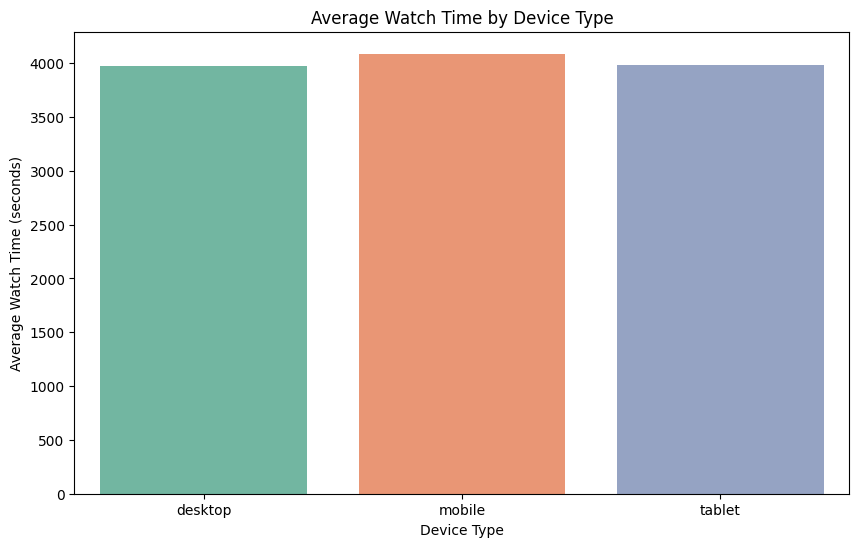

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(x=avg_watch_time_by_device.index,
            y=avg_watch_time_by_device.values,
            palette='Set2')   # different color for each bar

plt.title('Average Watch Time by Device Type')
plt.xlabel('Device Type')
plt.ylabel('Average Watch Time (seconds)')
plt.show()


**Sentiment Analysis**

In [ ]:
# Which sentiment performs best

# Create engagement_score
df['engagement_score'] = (df['likes'] + df['comments'] + df['shares']) / (df['follower_count'] + 1)

# Average engagement by sentiment
avg_by_sentiment = df.groupby('sentiment')[['likes', 'comments', 'shares', 'engagement_score']].mean()

# Sentiment with highest engagement score
highest_sentiment = avg_by_sentiment.loc[avg_by_sentiment['engagement_score'].idxmax()]

print("Sentiment with the highest average engagement score:")
highest_sentiment


Sentiment with the highest average engagement score:


,negative
likes,10208.096875
comments,1516.094792
shares,1007.307292
engagement_score,0.284645


In [ ]:
# Behavior of negative/neutral sentiment posts

# Average engagement for selected sentiments
avg_engagement = sentiment_filtered_df.groupby('sentiment')[['likes', 'comments', 'shares', 'engagement_score']].mean()

print("Average Engagement Metrics (Negative & Neutral):")
avg_engagement


Average Engagement Metrics (Negative & Neutral):


,likes,comments,shares,engagement_score
sentiment,,,,
negative,10208.096875,1516.094792,1007.307292,0.284645
neutral,9923.194499,1528.404060,996.565160,0.111559


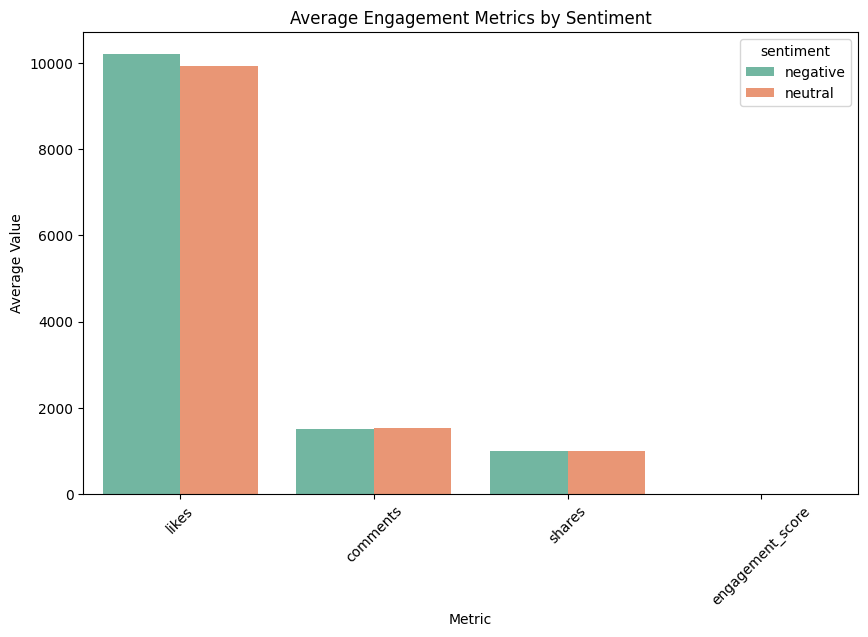

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data for plotting
plot_df = avg_engagement_by_filtered_sentiment.reset_index()
plot_df = plot_df.melt(id_vars='sentiment', var_name='metric', value_name='average_value')

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=plot_df, x='metric', y='average_value', hue='sentiment', palette='Set2')

plt.title('Average Engagement Metrics by Sentiment')
plt.xlabel('Metric')
plt.ylabel('Average Value')
plt.xticks(rotation=45)
plt.show()
